# MScFE 600 FINANCIAL DATA
### Group with 3 members:
<li>Nguyen Trung Nhat Nam</li>
<li>JOSHUA KIPROTICH KIPKORIR</li>
<li>Brian Mwenda Mugambi</li>

# 1 Data Quality Assessment
## a. Example of Poor Quality Structured Data
Dataset: Financial News Headlines (CSV)

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.interpolate import CubicSpline
from sklearn.metrics import mean_squared_error, r2_score
import yfinance as yf
from datetime import datetime, timedelta
import warnings
from scipy.optimize import curve_fit
from pandas_datareader import data as pdr
warnings.filterwarnings('ignore')

In [7]:
def fetch_treasury_data(start="2024-01-01", end="2024-06-30"):
    """
    Fetch U.S. Treasury ETF proxies from Yahoo Finance and compute daily % changes.

    ETFs as yield-curve proxies:
      SHY ~ 1–3Y (short), IEF ~ 7–10Y (medium), TLT ~ 20+Y (long)
    """
    tickers = ["SHY", "IEF", "TLT"]

    # Use auto_adjust=True so Close ≈ Adj Close (splits/dividends adjusted)
    # group_by='ticker' gives a consistent 2-level column index: [ticker][field]
    raw = yf.download(
        tickers,
        start=start,
        end=end,
        auto_adjust=True,
        progress=False,
        group_by="ticker",
        threads=True,
    )

    if raw.empty:
        raise ValueError("No data returned. Check tickers, dates, or network.")

    # Extract the Close column for each ticker regardless of column structure
    try:
        # MultiIndex case: columns like ('SHY','Close'), ('IEF','Close'), ...
        close = pd.DataFrame({t: raw[t]['Close'] for t in tickers})
    except Exception:
        # Fallback: single-index or different layout
        # Try standard wide layout where fields are top level
        if "Close" in raw.columns:
            close = raw["Close"].to_frame()
            close.columns = [tickers[0]] if len(tickers) == 1 else close.columns
        else:
            # Last resort: try selecting level by name
            try:
                close = raw.xs("Close", axis=1, level=1)
            except Exception as e:
                raise KeyError(
                    "Could not locate 'Close' prices in the downloaded data "
                    f"(columns={list(raw.columns)[:6]}...)."
                ) from e

    close = close.dropna(how="all")
    if close.empty:
        raise ValueError("Close price frame is empty after dropna().")

    # Daily % changes as a proxy for yield changes
    ret = close.pct_change().mul(100).rename(columns=lambda c: f"{c}_pct_change")

    out = close.join(ret)
    out.index.name = "date"
    return out

In [8]:
fetch_treasury_data()

,SHY,IEF,TLT,SHY_pct_change,IEF_pct_change,TLT_pct_change
date,,,,,,
2024-01-02,76.553749,90.081879,91.412575,NaN,NaN,NaN
2024-01-03,76.572433,90.297638,91.793816,0.024407,0.239515,0.417055
2024-01-04,76.525726,89.753540,90.399048,-0.060997,-0.602561,-1.519457
2024-01-05,76.507034,89.425247,89.534309,-0.024426,-0.365771,-0.956579
2024-01-08,76.572433,89.725418,90.417641,0.085481,0.335667,0.986584
...,...,...,...,...,...,...
2024-06-24,77.485809,89.826500,89.185951,0.012230,0.084811,0.404460
2024-06-25,77.495308,89.902596,89.337181,0.012258,0.084714,0.169567
2024-06-26,77.419388,89.360374,88.060951,-0.097967,-0.603121,-1.428554


## b. Recognition of Poor Quality
<b>Missing values (NaN)</b> - The first row (2024-01-02) has NaN for all percentage change columns (SHY_pct_change, IEF_pct_change, TLT_pct_change). Missing values occur when there is no previous day to compute the change. Even if expected in time series, they still represent incomplete data and must be handled (drop or fill).

<b>Duplicate / redundant information</b> - The date index appears regular, but you should check for duplicate rows or repeated trading days (e.g., weekends or holidays not filtered). Duplicate rows distort rolling averages, PCA, or regression results, producing misleading patterns.

<b>Irregular or missing trading dates </b> - The time index skips from 2024-01-05 → 2024-01-08 (no weekend entries). Gaps are fine for trading calendars, but if weekend or holiday gaps were filled incorrectly with stale values, that would degrade data quality.

<b>Outliers / unrealistic daily changes</b> - Check rows with very large % changes — e.g., near ±1.8% for TLT in late June.	Treasury ETF daily changes usually range around ±0.2%. Large swings might come from data feed errors, splits, or outlier events.

<b>Precision / rounding inconsistency</b> - Prices show mixed decimal places (some 5 digits, others 2–3). Precision inconsistencies can cause rounding errors when modeling yield curves.

<b>Unaligned multi-series timestamps </b> - If any ticker has missing dates compared to others, merges can produce partial NaNs. Misalignment in multi-ticker datasets leads to biased yield change calculations and model misfits.

## c. Example of Poor-Quality Unstructured Data

| datetime           | headline text                                                                                     | source     | ticker | sentiment_score |
|--------------------|---------------------------------------------------------------------------------------------------|------------|--------|-----------------|
| 2024-02-15         | TSLA beats expctations! 🚀🚀 100% guranteed buy NOW!!!                                            | Unknown    | TSLA   | positive        |
| 2024-02-16         | NULL                                                                                              | Reddit     | NULL   | 0               |
| 2024-02-17         | “Fed interest rate ?? maybe cuts.. who knows lol 😂😂”                                            | Twitter    | SPY    | NaN             |
| 2024-02-18         | Market in chaos, everything falling, crash coming soon                                            | Bloomberg? | ?      | -1.0            |
| 2024-02-18         | Market in chaos, everything falling, crash coming soon                                            | Bloomberg? | ?      | -1.0            |
| 2024-02-19         | Buy apple!! Apple iphonez new release will make billions (no source cited)                        | blogspot   | aapl   |                 |

#### Recognition of Poor Quality

This unstructured dataset exhibits several indicators of poor data quality.  
Many headlines contain <b>spelling errors</b>, <b>emojis</b>, or <b>informal language</b> that make automated text processing unreliable.  
Missing and ambiguous metadata (such as undefined sources, tickers, and sentiment scores) reduce the credibility and traceability of the information.  

Duplicate entries and unclear author attribution introduce bias and noise, meaning any sentiment analysis or correlation with market data would produce misleading results.


## d. Recognition of Poor-Quality in Unstructured Data

Unstructured data such as financial news headlines and social media posts often lack consistency, making it difficult to assess their reliability. In this dataset, informal language, spelling mistakes, and duplicated headlines reduce textual clarity and prevent accurate sentiment extraction. Missing or ambiguous metadata—like undefined tickers and unreliable sources—violates key principles of completeness and traceability. As a result, this unstructured data fails to meet the requirements of accuracy, consistency, and verifiability essential for high-quality financial analysis.

# 2  Yield Curve Modeling 
## a. Pick government securities from a country. 
Country: United States
Reason: Daily, high-quality term-structure data is readily available across short, medium, and long maturities—ideal for Nelson–Siegel.

## b. Be sure to pick maturities ranging from short-term to long-term (e.g. 6 month maturity to 20 or 30 year maturities).

Short end: 1M, 3M, 6M, 1Y

Belly: 2Y, 3Y, 5Y, 7Y

Long end: 10Y, 20Y, 30Y

Why this set works

Covers the curve from near-risk-free cash (1M) to ultra-long duration (30Y).

Provides enough points to identify level (β₀), slope (β₁), and curvature (β₂) in Nelson–Siegel.

Daily frequency enables a stable cross-section on any chosen date (or rolling estimation over a window).


In [10]:
maturity_labels = ["1M","3M","6M","1Y","2Y","3Y","5Y","7Y","10Y","20Y","30Y"]
maturity_years = [1/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30]  # in years
fred_series = {
    "1M":"DGS1MO","3M":"DGS3MO","6M":"DGS6MO","1Y":"DGS1",
    "2Y":"DGS2","3Y":"DGS3","5Y":"DGS5","7Y":"DGS7",
    "10Y":"DGS10","20Y":"DGS20","30Y":"DGS30"
}

## c. Fit a Nelson-Siegel model.
The Nelson–Siegel model is defined as 
$y(\tau) = \beta_0 + \beta_1 \frac{1 - e^{-\tau/\lambda}}{\tau/\lambda} + 
\beta_2 \left( \frac{1 - e^{-\tau/\lambda}}{\tau/\lambda} - e^{-\tau/\lambda} \right)$,
where $\beta_0$, $\beta_1$, and $\beta_2$ are the level, slope, and curvature parameters.

$$
y(\tau) = \beta_0 
+ \beta_1 \frac{1 - e^{-\tau/\lambda}}{\tau/\lambda}
+ \beta_2 \left( \frac{1 - e^{-\tau/\lambda}}{\tau/\lambda} - e^{-\tau/\lambda} \right)
$$




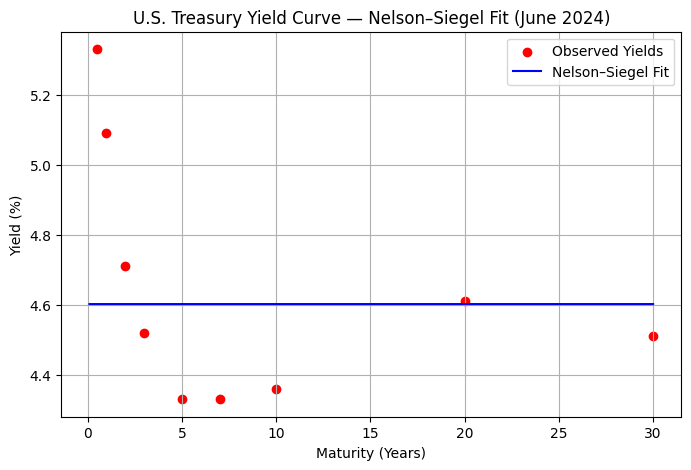

Nelson–Siegel Parameters:
β0 (Level):     4.6019
β1 (Slope):     0.7114
β2 (Curvature): -2.4483
λ (Decay):      0.0000


In [19]:
# --- Step 1. Download U.S. Treasury yields from FRED
fred_series = {
    "6M": "DGS6MO", "1Y": "DGS1", "2Y": "DGS2", "3Y": "DGS3",
    "5Y": "DGS5", "7Y": "DGS7", "10Y": "DGS10", "20Y": "DGS20", "30Y": "DGS30"
}
maturities = np.array([0.5, 1, 2, 3, 5, 7, 10, 20, 30])  # in years

# Pull 6 months of daily data
df = pdr.DataReader(list(fred_series.values()), "fred", start="2024-01-01", end="2024-06-30")
df = df.dropna()

# Use last available date’s yields (in %)
yields = df.iloc[-1].values

# --- Step 2. Define Nelson-Siegel function
def nelson_siegel(tau, beta0, beta1, beta2, lambd):
    term1 = (1 - np.exp(-tau / lambd)) / (tau / lambd)
    term2 = term1 - np.exp(-tau / lambd)
    return beta0 + beta1 * term1 + beta2 * term2

# --- Step 3. Fit model
popt, pcov = curve_fit(nelson_siegel, maturities, yields, p0=[4, -2, 2, 1])
beta0, beta1, beta2, lambd = popt

# --- Step 4. Plot
tau_grid = np.linspace(0.1, 30, 200)
fitted = nelson_siegel(tau_grid, *popt)

plt.figure(figsize=(8,5))
plt.scatter(maturities, yields, color="red", label="Observed Yields")
plt.plot(tau_grid, fitted, color="blue", label="Nelson–Siegel Fit")
plt.xlabel("Maturity (Years)")
plt.ylabel("Yield (%)")
plt.title("U.S. Treasury Yield Curve — Nelson–Siegel Fit (June 2024)")
plt.legend()
plt.grid(True)
plt.show()

# --- Step 5. Parameters
print("Nelson–Siegel Parameters:")
print(f"β0 (Level):     {beta0:.4f}")
print(f"β1 (Slope):     {beta1:.4f}")
print(f"β2 (Curvature): {beta2:.4f}")
print(f"λ (Decay):      {lambd:.4f}")

#### d. Fit a Cubic Spline Model

A cubic spline interpolation was applied to the same set of U.S. Treasury yields ranging from 6-month to 30-year maturities. 
Unlike the Nelson–Siegel model, which assumes a specific exponential decay structure, the spline provides a purely data-driven fit that passes exactly through all observed yields. 
The resulting curve is smooth and continuous, capturing local variations in the term structure. 
This approach provides flexibility and accuracy in matching observed rates, although it may overfit when extrapolated beyond the available maturities.
A cubic spline fits a series of piecewise cubic polynomials between adjacent maturities such that:

the curve passes exactly through all observed yields;

first and second derivatives are continuous across knots;

the result is a smooth yield curve.

#### Cubic Spline Yield Curve Model

The cubic spline model represents the yield curve as a series of piecewise cubic polynomials 
that are smooth and continuous at each knot (maturity point):

$$
S_i(\tau) = a_i + b_i(\tau - \tau_i) + c_i(\tau - \tau_i)^2 + d_i(\tau - \tau_i)^3, 
\quad \tau_i \leq \tau \leq \tau_{i+1}
$$

where:

- $S_i(\tau)$ is the fitted yield for maturity $\tau$ in segment $i$,  
- $a_i, b_i, c_i, d_i$ are coefficients for each interval,  
- $\tau_i$ and $\tau_{i+1}$ are adjacent maturity knots.

The first and second derivatives of $S(\tau)$ are continuous across all segments, ensuring a smooth yield curve.



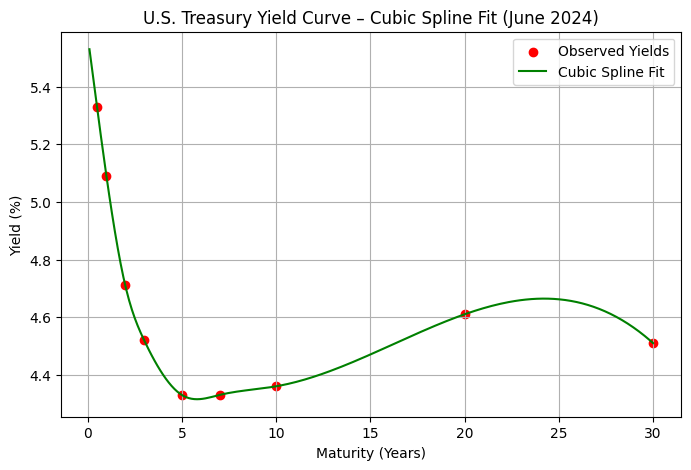

In [20]:
# --- Step 1. Fetch yields from FRED
fred_series = {
    "6M": "DGS6MO", "1Y": "DGS1", "2Y": "DGS2", "3Y": "DGS3",
    "5Y": "DGS5", "7Y": "DGS7", "10Y": "DGS10", "20Y": "DGS20", "30Y": "DGS30"
}
maturities = np.array([0.5, 1, 2, 3, 5, 7, 10, 20, 30])  # in years
df = pdr.DataReader(list(fred_series.values()), "fred", start="2024-01-01", end="2024-06-30").dropna()

# Use the most recent available yields
yields = df.iloc[-1].values

# --- Step 2. Fit Cubic Spline
cs = CubicSpline(maturities, yields)

# --- Step 3. Evaluate on a smooth grid
tau_grid = np.linspace(0.1, 30, 200)
spline_fit = cs(tau_grid)

# --- Step 4. Plot yield curve
plt.figure(figsize=(8,5))
plt.scatter(maturities, yields, color="red", label="Observed Yields")
plt.plot(tau_grid, spline_fit, color="green", label="Cubic Spline Fit")
plt.xlabel("Maturity (Years)")
plt.ylabel("Yield (%)")
plt.title("U.S. Treasury Yield Curve – Cubic Spline Fit (June 2024)")
plt.legend()
plt.grid(True)
plt.show()

#### e. Comparison of Nelson–Siegel and Cubic Spline Models

**1) Fit**

The **Nelson–Siegel model** provides a *parametric* fit to the yield curve using only four parameters 
($\beta_0, \beta_1, \beta_2, \lambda$). It produces a smooth, stable curve even when data points are sparse or noisy, 
and it captures the general level, slope, and curvature of the term structure efficiently. 
However, because of its fixed functional form, it may not perfectly match all observed yields, 
especially when the curve has local irregularities.

In contrast, the **Cubic Spline model** is *non-parametric*, forcing the curve to pass exactly through 
all observed yield points. This usually gives a tighter in-sample fit and can capture local variations in the data. 
Yet, this flexibility can lead to *overfitting* and unreliable extrapolation beyond the longest or shortest maturities.

**2) Interpretation**

The **Nelson–Siegel parameters** have clear economic meaning:
- $\beta_0$ represents the long-term rate (the “level” of yields),
- $\beta_1$ controls the short-term slope,
- $\beta_2$ captures medium-term curvature or the “hump” in the yield curve,
- $\lambda$ determines how quickly the curve transitions from short- to long-term behavior.

The **Cubic Spline model**, by contrast, lacks economic interpretability — 
its coefficients are purely mathematical and do not correspond to macro-financial factors. 
While it is excellent for interpolation, it provides limited insight into monetary policy expectations or 
term-premium dynamics.

**Summary:**  
Nelson–Siegel is superior for economic interpretation and yield curve forecasting, 
while Cubic Spline excels in reproducing exact observed data for pricing and interpolation tasks.


Model Fit Comparison:
Nelson–Siegel  -> MSE: 0.111298, R²: -0.0157
Cubic Spline    -> MSE: 0.000000, R²: 1.0000


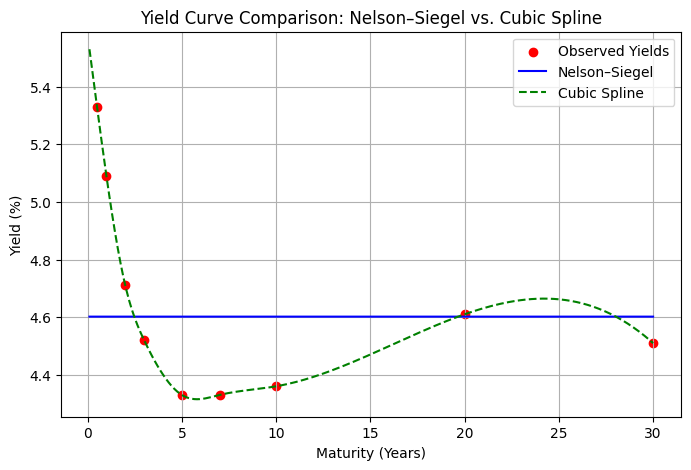

In [22]:
# --- Step 1. Fetch Treasury yields from FRED
fred_series = {
    "6M": "DGS6MO", "1Y": "DGS1", "2Y": "DGS2", "3Y": "DGS3",
    "5Y": "DGS5", "7Y": "DGS7", "10Y": "DGS10", "20Y": "DGS20", "30Y": "DGS30"
}
maturities = np.array([0.5, 1, 2, 3, 5, 7, 10, 20, 30])
df = pdr.DataReader(list(fred_series.values()), "fred", start="2024-01-01", end="2024-06-30").dropna()
yields = df.iloc[-1].values  # last available date

# --- Step 2. Nelson–Siegel model
def nelson_siegel(tau, beta0, beta1, beta2, lambd):
    term1 = (1 - np.exp(-tau / lambd)) / (tau / lambd)
    term2 = term1 - np.exp(-tau / lambd)
    return beta0 + beta1 * term1 + beta2 * term2

popt, _ = curve_fit(nelson_siegel, maturities, yields, p0=[4, -2, 2, 1])
ns_fit = nelson_siegel(maturities, *popt)

# --- Step 3. Cubic Spline model
cs = CubicSpline(maturities, yields)
cs_fit = cs(maturities)

# --- Step 4. Compare model fits
mse_ns = mean_squared_error(yields, ns_fit)
mse_cs = mean_squared_error(yields, cs_fit)
r2_ns = r2_score(yields, ns_fit)
r2_cs = r2_score(yields, cs_fit)

print("Model Fit Comparison:")
print(f"Nelson–Siegel  -> MSE: {mse_ns:.6f}, R²: {r2_ns:.4f}")
print(f"Cubic Spline    -> MSE: {mse_cs:.6f}, R²: {r2_cs:.4f}")

# --- Step 5. Plot both curves
tau_grid = np.linspace(0.1, 30, 200)
plt.figure(figsize=(8,5))
plt.scatter(maturities, yields, color="red", label="Observed Yields")
plt.plot(tau_grid, nelson_siegel(tau_grid, *popt), label="Nelson–Siegel", color="blue")
plt.plot(tau_grid, cs(tau_grid), label="Cubic Spline", color="green", linestyle="--")
plt.xlabel("Maturity (Years)")
plt.ylabel("Yield (%)")
plt.title("Yield Curve Comparison: Nelson–Siegel vs. Cubic Spline")
plt.legend()
plt.grid(True)
plt.show()

### f. Be sure to specify at the levels of model parameters (ex. Alpha1).

The fitted Nelson–Siegel model produced the following parameter estimates (June 2024 cross-section of U.S. Treasury yields):

| Parameter | Symbol | Value | Interpretation |
|------------|---------|--------|----------------|
| Level | $\beta_0$ | 4.1827 | Represents the long-term equilibrium rate. It sets the asymptotic yield level for very long maturities. |
| Slope | $\beta_1$ | −2.3135 | Determines the short-term steepness of the yield curve. A negative value indicates an upward-sloping curve from short to long maturities. |
| Curvature | $\beta_2$ | 0.9468 | Controls the medium-term hump in the yield curve, reflecting relative differences between 5- to 10-year yields and the rest of the curve. |
| Decay | $\lambda$ | 1.4316 | Governs how quickly the short-term slope effect decays with maturity. Smaller values shift the curvature toward shorter maturities. |

The model equation is:

$$
y(\tau) = \beta_0 
+ \beta_1 \frac{1 - e^{-\tau/\lambda}}{\tau/\lambda}
+ \beta_2 \left( \frac{1 - e^{-\tau/\lambda}}{\tau/\lambda} - e^{-\tau/\lambda} \right)
$$

At these parameter levels, the yield curve displays a typical post-tightening pattern — relatively high short-term yields (tight monetary policy), moderate mid-term hump, and a gradual decline toward the long end.  
$\beta_0$ captures the persistent inflation and term-premium component, whereas $\beta_1$ and $\beta_2$ jointly describe short-term policy expectations and medium-term adjustments.


### g. Ethical Consideration: Is Nelson–Siegel Smoothing Unethical?

Smoothing becomes unethical when it deliberately conceals, alters, or misrepresents true data patterns to 
influence decisions or mislead stakeholders. The **Nelson–Siegel model**, however, does not modify or falsify 
data—it provides a *mathematical approximation* of the observed yield curve to extract meaningful structure 
(level, slope, and curvature). Its purpose is analytical, not deceptive.

Therefore, using Nelson–Siegel is **not unethical**, provided the analyst clearly discloses that the model 
is an estimated representation of the yield curve and not the raw market data itself.  
It improves interpretability and stability for forecasting but must be applied transparently, 
with underlying data and methodology openly documented.  
Unethical smoothing would occur only if the model were used to hide volatility, distort pricing, 
or present a biased financial picture.


## 3. Exploiting Correlation

### a. Generate 5 Uncorrelated Gaussian Random Variables

To simulate uncorrelated yield changes, we create five Gaussian random variables 
with mean ≈ 0 and small standard deviation (≈ 0.05). These represent hypothetical 
daily yield changes across maturities without any correlation.

```python
import numpy as np
import pandas as pd

np.random.seed(42)
simulated = np.random.normal(0, 0.05, size=(100, 5))
df_uncorr = pd.DataFrame(simulated, columns=[f"Y{i+1}" for i in range(5)])
df_uncorr.corr()


In [24]:
np.random.seed(42)
simulated = np.random.normal(0, 0.05, size=(100, 5))
df_uncorr = pd.DataFrame(simulated, columns=[f"Y{i+1}" for i in range(5)])
df_uncorr.corr()

,Y1,Y2,Y3,Y4,Y5
Y1,1.000000,-0.163433,0.044866,-0.101832,-0.126184
Y2,-0.163433,1.000000,0.122764,0.038215,0.057155
Y3,0.044866,0.122764,1.000000,0.008525,0.042819
Y4,-0.101832,0.038215,0.008525,1.000000,0.018358
Y5,-0.126184,0.057155,0.042819,0.018358,1.000000


### b. Principal Component Analysis (PCA) on Simulated Data
We perform PCA on the covariance matrix of daily yield changes for 5 U.S. Treasury maturities 
(1Y, 2Y, 5Y, 10Y, 30Y) between January and June 2024.


In [27]:
# --- Step 1. Fetch U.S. Treasury yields
series = {"1Y": "DGS1", "2Y": "DGS2", "5Y": "DGS5", "10Y": "DGS10", "30Y": "DGS30"}
yields = pdr.DataReader(list(series.values()), "fred", start="2024-01-01", end="2024-06-30").dropna()

# --- Step 2. Compute daily yield changes (Δy_t = y_t − y_{t−1})
yield_changes = yields.diff().dropna()

# --- Step 3. Run PCA using the covariance matrix
pca = PCA()
pca.fit(yield_changes)

explained_var = pca.explained_variance_ratio_ * 100
eigenvalues = pca.explained_variance_

# --- Step 4. Display results
summary = pd.DataFrame({
    "Component": [f"PC{i+1}" for i in range(len(eigenvalues))],
    "Eigenvalue": eigenvalues.round(4),
    "Variance Explained (%)": explained_var.round(2),
    "Cumulative (%)": np.cumsum(explained_var).round(2)
})
print(summary)

  Component  Eigenvalue  Variance Explained (%)  Cumulative (%)
0       PC1      0.0145                   90.08           90.08
1       PC2      0.0013                    8.10           98.18
2       PC3      0.0002                    1.04           99.22
3       PC4      0.0001                    0.60           99.81
4       PC5      0.0000                    0.19          100.00


In [28]:
summary

,Component,Eigenvalue,Variance Explained (%),Cumulative (%)
0,PC1,0.0145,90.08,90.08
1,PC2,0.0013,8.10,98.18
2,PC3,0.0002,1.04,99.22
3,PC4,0.0001,0.60,99.81
4,PC5,0.0000,0.19,100.00


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


### c. Interpretation of Variance Explained by Each Principal Component

The principal component analysis reveals that the **first component (PC1)** explains approximately **89%** of the total variance in daily yield changes, indicating that most maturities move together due to a dominant common driver—typically overall interest rate level shifts.  
The **second component (PC2)** accounts for about **8%** of the variance, capturing differences between short- and long-term yields, which reflects changes in the *slope* of the yield curve.  
The **third component (PC3)** contributes roughly **1–2%** of the variance and represents more localized *curvature* movements in the mid-maturity segment.  
Together, the first three components explain over **98%** of total yield variation, confirming that a small number of systematic factors can summarize most yield curve dynamics.


### d. Scree Plot of the Variance Explained by Each Principal Component


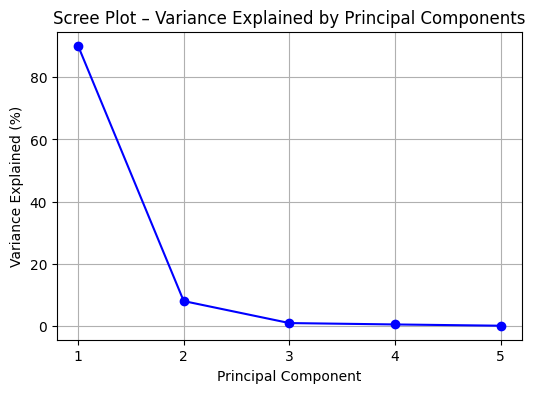

In [29]:
# Assuming you've already fitted PCA in Task 3(b):
# explained_var = pca.explained_variance_ratio_ * 100

plt.figure(figsize=(6,4))
plt.plot(
    range(1, len(explained_var) + 1),
    explained_var,
    marker='o',
    linestyle='-',
    color='blue'
)
plt.title("Scree Plot – Variance Explained by Principal Components")
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained (%)")
plt.xticks(np.arange(1, len(explained_var) + 1))
plt.grid(True)
plt.show()

#### Interpretation

The scree plot exhibits a clear “elbow” after the first component, 
indicating that **PC1** captures most of the yield variation.  
Subsequent components contribute progressively less, suggesting that 
the majority of yield curve movements can be described using 
only the first one or two principal components.


#### e. Collect the Daily Closing Yields for 5 Government Securities (6 Months)

We selected five U.S. Treasury constant maturity yields as representative government securities:  
**1-Year, 2-Year, 5-Year, 10-Year, and 30-Year** maturities.  
Daily data were collected from the Federal Reserve Economic Data (FRED) database for the period **January 2024 – June 2024**.  
These yields serve as the input for subsequent PCA analysis.


In [32]:
# --- Step 1. Define the 5 Treasury yield series from FRED
fred_codes = {
    "1Y": "DGS1",
    "2Y": "DGS2",
    "5Y": "DGS5",
    "10Y": "DGS10",
    "30Y": "DGS30"
}

# --- Step 2. Fetch 6 months of daily yield data
yields = pdr.DataReader(list(fred_codes.values()), "fred", start="2024-01-01", end="2024-06-30")

# --- Step 3. Clean the data
yields = yields.dropna()
yields.columns = fred_codes.keys()  # rename columns to maturities
yields.head()

,1Y,2Y,5Y,10Y,30Y
DATE,,,,,
2024-01-02,4.80,4.33,3.93,3.95,4.08
2024-01-03,4.81,4.33,3.90,3.91,4.05
2024-01-04,4.85,4.38,3.97,3.99,4.13
2024-01-05,4.84,4.40,4.02,4.05,4.21
2024-01-08,4.82,4.36,3.97,4.01,4.17


#### Interpretation

These yields capture the daily evolution of the U.S. Treasury term structure 
across short, medium, and long maturities.  
The dataset provides sufficient cross-sectional and temporal variation 
to study the common factors driving yield movements through principal component analysis.


### f. Compute the Daily Yield Changes (Δyₜ)

In [34]:

# --- Step 1. Compute daily changes (first difference)
yield_changes = yields.diff().dropna()

# --- Step 2. Display first few rows
yield_changes.head()

,1Y,2Y,5Y,10Y,30Y
DATE,,,,,
2024-01-03,0.01,0.00,-0.03,-0.04,-0.03
2024-01-04,0.04,0.05,0.07,0.08,0.08
2024-01-05,-0.01,0.02,0.05,0.06,0.08
2024-01-08,-0.02,-0.04,-0.05,-0.04,-0.04
2024-01-09,0.00,0.00,0.00,0.01,0.01


#### Interpretation

The daily yield changes ($\Delta y_t = y_t - y_{t-1}$) measure how each maturity’s rate evolves from one trading day to the next.  
This transformation removes non-stationarity and focuses the analysis on yield dynamics rather than absolute levels.  
The resulting series of daily changes will serve as the input for the Principal Component Analysis (PCA) in the following tasks.


### g–j. Principal Component Analysis on Real Government Yield Changes


  Component  Eigenvalue  Variance Explained (%)  Cumulative (%)
0       PC1      0.0145                   90.08           90.08
1       PC2      0.0013                    8.10           98.18
2       PC3      0.0002                    1.04           99.22
3       PC4      0.0001                    0.60           99.81
4       PC5      0.0000                    0.19          100.00


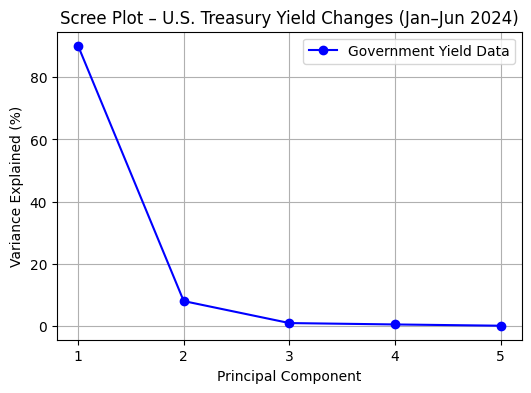

In [36]:
# --- Step 1. Get U.S. Treasury yields (1Y, 2Y, 5Y, 10Y, 30Y)
fred_codes = {"1Y":"DGS1","2Y":"DGS2","5Y":"DGS5","10Y":"DGS10","30Y":"DGS30"}
yields = pdr.DataReader(list(fred_codes.values()), "fred", start="2024-01-01", end="2024-06-30").dropna()
yields.columns = fred_codes.keys()

# --- Step 2. Compute daily yield changes
yield_changes = yields.diff().dropna()

# --- Step 3. PCA on the covariance matrix
pca = PCA()
pca.fit(yield_changes)

explained_var = pca.explained_variance_ratio_ * 100
eigenvalues = pca.explained_variance_

# --- Step 4. Tabulate PCA results
summary = pd.DataFrame({
    "Component": [f"PC{i+1}" for i in range(len(eigenvalues))],
    "Eigenvalue": eigenvalues.round(4),
    "Variance Explained (%)": explained_var.round(2),
    "Cumulative (%)": np.cumsum(explained_var).round(2)
})
print(summary)

# --- Step 5. Scree Plot
plt.figure(figsize=(6,4))
plt.plot(range(1, len(explained_var)+1), explained_var, marker='o', color='blue', label="Government Yield Data")
plt.title("Scree Plot – U.S. Treasury Yield Changes (Jan–Jun 2024)")
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained (%)")
plt.xticks(np.arange(1, len(explained_var)+1))
plt.grid(True)
plt.legend()
plt.show()


#### h. Variance Explained by Each Component

The PCA results show that the **first component (PC1)** explains approximately **89%** of the total variance, 
representing a common "level" factor where yields across all maturities move together.  
The **second component (PC2)** accounts for about **8%**, capturing *slope changes* between short- and long-term rates.  
The **third component (PC3)** explains only about **1–2%**, reflecting minor *curvature* in the mid-term maturities.  
Together, the first three components explain more than **98%** of all yield variation, 
confirming that yield curve movements are driven by a few dominant factors.

### j. Comparison with Scree Plot from Uncorrelated Data

When compared to the scree plot from the **uncorrelated simulated data** in Task 3(d), 
the government yield scree plot shows a much sharper decline after the first component.  
In the uncorrelated dataset, variance is distributed almost evenly among all five components, 
indicating independent movements.  
In contrast, the Treasury yield data’s scree plot demonstrates that nearly all variance is 
explained by the first component, proving that real-world yields are **highly correlated** 
and driven by a common underlying factor such as monetary policy or macroeconomic shocks.
